### Olist 데이터셋 - 브라질 이커머스 데이터

In [19]:
import pandas as pd # 데이터 처리
import matplotlib.pyplot as plt # 그래프
from sqlalchemy import create_engine # mysql 연결

In [20]:
## MYSQL 연결

username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "olist_project"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

In [21]:
# 연결 확인
pd.read_sql(
    "SELECT 1",
    engine
)

,1
0,1


### 매출 분석

In [22]:
## 월별 매출

query = """
SELECT 
    DATE_FORMAT(o.order_purchase_timestamp, '%%Y-%%m') AS order_month,
    ROUND(SUM(oi.price), 2) AS revenue
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY order_month
ORDER BY order_month;
"""

df_revenue = pd.read_sql(query, engine)

df_revenue.head()

,order_month,revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


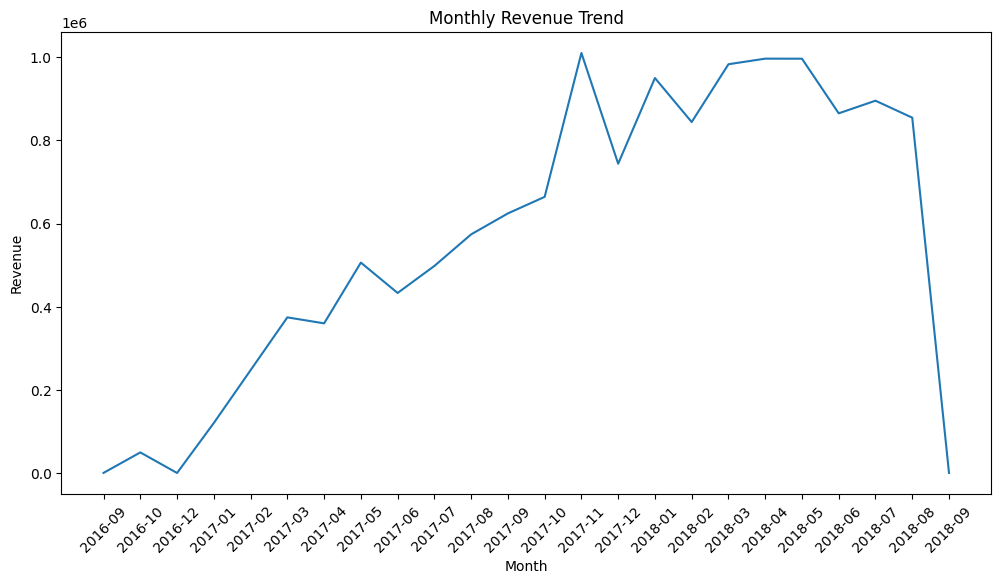

In [23]:
## 월별 매출 그래프

plt.figure(figsize=(12,6))

plt.plot(
    df_revenue['order_month'],
    df_revenue['revenue']
)

plt.xticks(rotation=45)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

### 상품 분석

In [45]:
## 카테고리별 판매량 TOP 10

query = """
SELECT
    ct.product_category_name_english AS category,
    COUNT(*) AS total_sales
FROM order_items oi

JOIN products p
    ON oi.product_id = p.product_id

JOIN category_translation ct
    ON p.product_category_name = ct.product_category_name

GROUP BY category

ORDER BY total_sales DESC

LIMIT 10;
"""

df_category = pd.read_sql(query, engine)

df_category

,category,total_sales
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


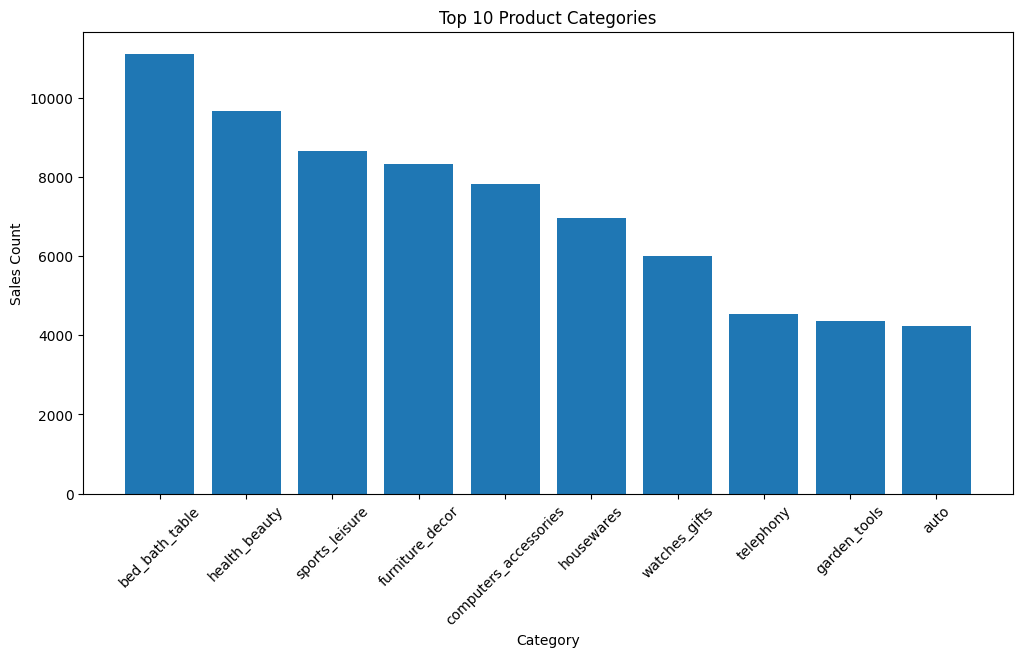

In [46]:
## 시각화
plt.figure(figsize=(12,6))

plt.bar(
    df_category['category'],
    df_category['total_sales']
)

plt.xticks(rotation=45)

plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Sales Count')

plt.show()

## 침구, 생활용품, 뷰티 카테고리 주문이 많음
## 자주 소비되는 상품군이 주문량 상위권에 많이 포함됨

In [36]:
## 카테고리별 매출액 TOP 10

query = """
SELECT
    ct.product_category_name_english AS category,
    ROUND(SUM(p.payment_value), 2) AS revenue

FROM order_items oi

JOIN products pr
    ON oi.product_id = pr.product_id

JOIN category_translation ct
    ON pr.product_category_name = ct.product_category_name

JOIN payments p
    ON oi.order_id = p.order_id

GROUP BY category

ORDER BY revenue DESC

LIMIT 10;
"""

df_category_revenue = pd.read_sql(query, engine)

df_category_revenue

,category,revenue
0,bed_bath_table,1712553.67
1,health_beauty,1657373.12
2,computers_accessories,1585330.45
3,furniture_decor,1430176.39
4,watches_gifts,1429216.68
5,sports_leisure,1392127.56
6,housewares,1094758.13
7,auto,852294.33
8,garden_tools,838280.75
9,cool_stuff,779698.00


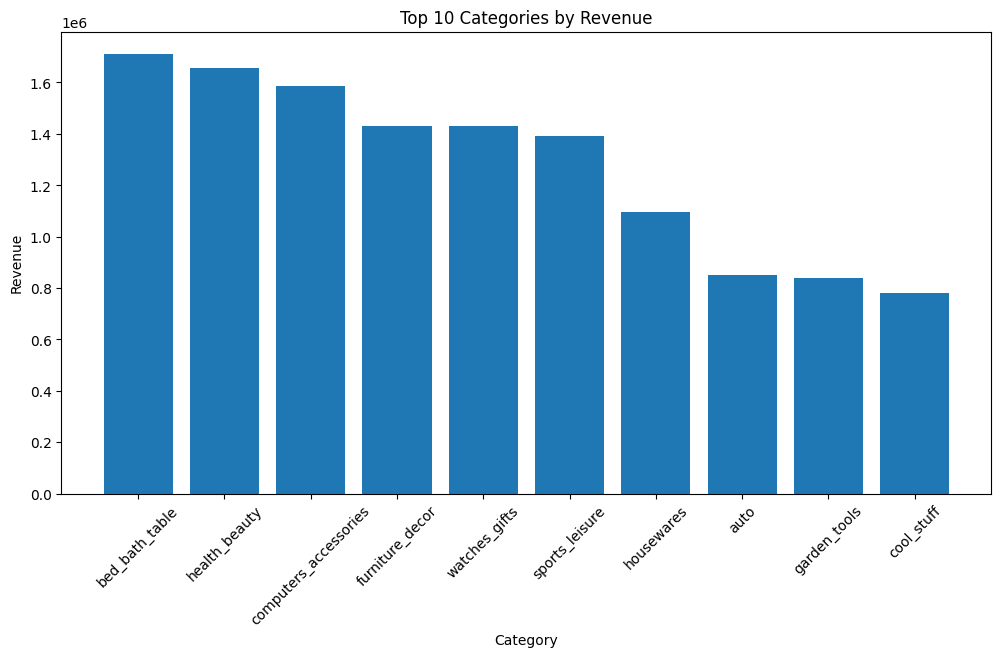

In [37]:
plt.figure(figsize=(12,6))

plt.bar(
    df_category_revenue['category'],
    df_category_revenue['revenue']
)

plt.xticks(rotation=45)

plt.title('Top 10 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()

In [44]:
df_category_revenue.head(10)

,category,revenue
0,bed_bath_table,1712553.67
1,health_beauty,1657373.12
2,computers_accessories,1585330.45
3,furniture_decor,1430176.39
4,watches_gifts,1429216.68
5,sports_leisure,1392127.56
6,housewares,1094758.13
7,auto,852294.33
8,garden_tools,838280.75
9,cool_stuff,779698.00


**카테고리별 매출 분석 결과**
- bed_bath_table(침구.생활용품), healty_beauty(뷰티), computers_accessories(컴퓨터 액세서리)가 높은 매출을 기록함.

- 특히 bed_bath_table은 판매량과 매출 모두 상위권에 위치하여 플램폿의 핵심 매출 카테고리임을 확인함.

In [47]:
## 전체 카테고리 매출

query = """
SELECT
    ct.product_category_name_english AS category,
    ROUND(SUM(p.payment_value), 2) AS revenue

FROM order_items oi

JOIN products pr
    ON oi.product_id = pr.product_id

JOIN category_translation ct
    ON pr.product_category_name = ct.product_category_name

JOIN payments p
    ON oi.order_id = p.order_id

GROUP BY category

ORDER BY revenue DESC;
"""

df_category_revenue_all = pd.read_sql(query, engine)

df_category_revenue_all.head()

,category,revenue
0,bed_bath_table,1712553.67
1,health_beauty,1657373.12
2,computers_accessories,1585330.45
3,furniture_decor,1430176.39
4,watches_gifts,1429216.68


In [48]:
# 매출 비중 계산

df_category_revenue_all['revenue_pct'] = (
    df_category_revenue_all['revenue']
    / df_category_revenue_all['revenue'].sum()
    * 100
)

df_category_revenue_all.head(10)

,category,revenue,revenue_pct
0,bed_bath_table,1712553.67,8.541916
1,health_beauty,1657373.12,8.266685
2,computers_accessories,1585330.45,7.907349
3,furniture_decor,1430176.39,7.133468
4,watches_gifts,1429216.68,7.128681
5,sports_leisure,1392127.56,6.943687
6,housewares,1094758.13,5.460461
7,auto,852294.33,4.251094
8,garden_tools,838280.75,4.181197
9,cool_stuff,779698.00,3.888996


In [49]:
# 누적 비중 계산

df_category_revenue_all['cum_pct'] = (
    df_category_revenue_all['revenue_pct']
    .cumsum()
)

df_category_revenue_all.head(10)

,category,revenue,revenue_pct,cum_pct
0,bed_bath_table,1712553.67,8.541916,8.541916
1,health_beauty,1657373.12,8.266685,16.808602
2,computers_accessories,1585330.45,7.907349,24.715951
3,furniture_decor,1430176.39,7.133468,31.849419
4,watches_gifts,1429216.68,7.128681,38.978100
5,sports_leisure,1392127.56,6.943687,45.921788
6,housewares,1094758.13,5.460461,51.382248
7,auto,852294.33,4.251094,55.633343
8,garden_tools,838280.75,4.181197,59.814539
9,cool_stuff,779698.00,3.888996,63.703536


In [50]:
# 상위 10개

df_category_revenue_all[
    ['category','revenue','revenue_pct','cum_pct']
].head(10)

,category,revenue,revenue_pct,cum_pct
0,bed_bath_table,1712553.67,8.541916,8.541916
1,health_beauty,1657373.12,8.266685,16.808602
2,computers_accessories,1585330.45,7.907349,24.715951
3,furniture_decor,1430176.39,7.133468,31.849419
4,watches_gifts,1429216.68,7.128681,38.978100
5,sports_leisure,1392127.56,6.943687,45.921788
6,housewares,1094758.13,5.460461,51.382248
7,auto,852294.33,4.251094,55.633343
8,garden_tools,838280.75,4.181197,59.814539
9,cool_stuff,779698.00,3.888996,63.703536


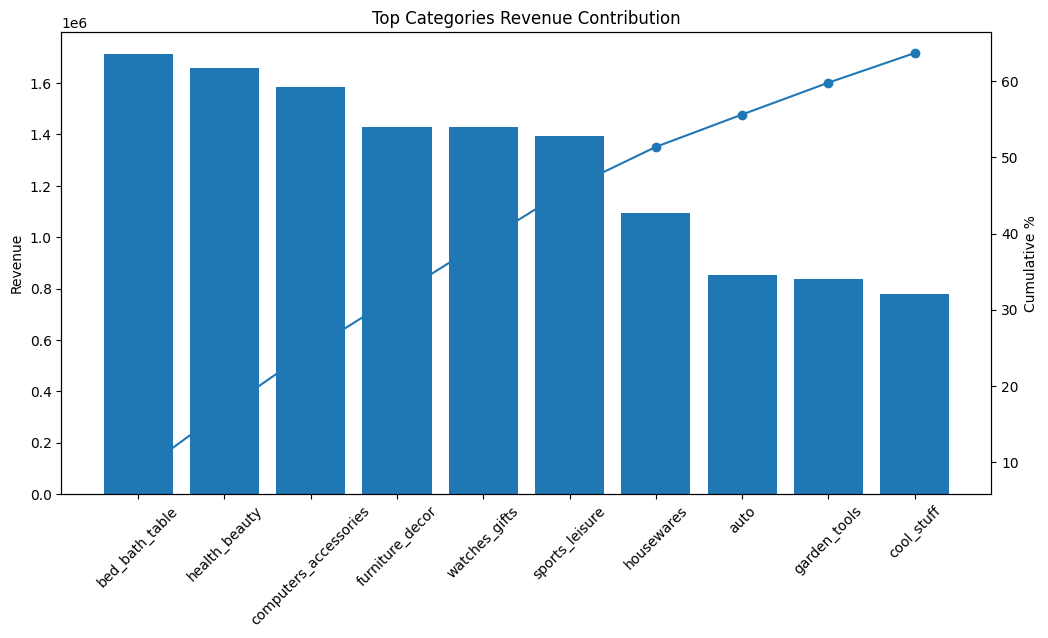

In [63]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    df_category_revenue_all['category'][:10],
    df_category_revenue_all['revenue'][:10]
)

ax1.set_ylabel('Revenue')

plt.xticks(rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    df_category_revenue_all['category'][:10],
    df_category_revenue_all['cum_pct'][:10],
    marker='o'
)

ax2.set_ylabel('Cumulative %')

plt.title('Top Categories Revenue Contribution')

plt.show()

**카테고리별 매출 비중 분석 결과**
- bed_bath_table, health_beauty, computers_accessories가 주요 매출 카테고리로 확인됨.

- 상위 5개 카테고리는 전체 매출의 약 39%를 차지하고 상위 10개 카테고리는 약 64%의 매출을 발생시킴.

- 특정 카테고리에만 매출이 집중된 구조라기보다 여러 카테고리에서 고르게 매출이 발생하는 플랫폼 특성을 확인할 수 있음.

In [64]:
# 카테고리별 매출 총합
df_category_revenue_all['revenue'].sum()

np.float64(20048822.920000006)

In [65]:
query = """
SELECT SUM(payment_value) AS total_revenue
FROM payments;
"""

# 실제 총 매출
pd.read_sql(query, engine)

,total_revenue
0,1.600887e+07


카테고리별 매출 합계와 실제 총 매출이 약 4,039,953 차이.

하나의 주문에는 여러 상품이 들어가 있을 수 있음.

payment_value와 order_items를 직접 조인 -> 중복

In [66]:
query = """
SELECT
    ct.product_category_name_english AS category,
    ROUND(SUM(oi.price), 2) AS revenue

FROM order_items oi

JOIN products pr
    ON oi.product_id = pr.product_id

JOIN category_translation ct
    ON pr.product_category_name = ct.product_category_name

GROUP BY category

ORDER BY revenue DESC

LIMIT 10;
"""

df_category_revenue = pd.read_sql(query, engine)

df_category_revenue

,category,revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


In [67]:
## 카테고리 매출 재계산

query = """
SELECT
    ct.product_category_name_english AS category,
    ROUND(SUM(oi.price), 2) AS revenue

FROM order_items oi

JOIN products pr
    ON oi.product_id = pr.product_id

JOIN category_translation ct
    ON pr.product_category_name = ct.product_category_name

GROUP BY category

ORDER BY revenue DESC;
"""

df_category_revenue = pd.read_sql(query, engine)

df_category_revenue.head(10)

,category,revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


In [68]:
df_category_revenue['revenue'].sum()

np.float64(13406593.939999998)

In [69]:
query = """
SELECT ROUND(SUM(price), 2) AS total_price
FROM order_items;
"""

pd.read_sql(query, engine)

,total_price
0,13591643.7


In [70]:
## 매출 비중 계산

df_category_revenue['revenue_pct'] = (
    df_category_revenue['revenue']
    / df_category_revenue['revenue'].sum()
    * 100
)

df_category_revenue['cum_pct'] = (
    df_category_revenue['revenue_pct']
    .cumsum()
)

df_category_revenue.head(10)
# 상위 10개 카테고리 -> 전체 매출의 62%
# 핵심 카테고리가 존재하지만 특정 상품군에만 의지하지 않는 구조

,category,revenue,revenue_pct,cum_pct
0,health_beauty,1258681.34,9.388524,9.388524
1,watches_gifts,1205005.68,8.988157,18.376681
2,bed_bath_table,1036988.68,7.734915,26.111596
3,sports_leisure,988048.97,7.369873,33.481470
4,computers_accessories,911954.32,6.802282,40.283752
5,furniture_decor,729762.49,5.443310,45.727062
6,cool_stuff,635290.85,4.738645,50.465706
7,housewares,632248.66,4.715953,55.181659
8,auto,592720.11,4.421109,59.602768
9,garden_tools,485256.46,3.619536,63.222304


- Healty & Beauty 매출 1위 확인함.
- Watches & Gifts는 매출 건수보다 매출이 높은 것으로 보아 높은 객단가로 추정됨.
- 상위 10개 카테고리가 전체 매출의 약 64% 차지함.

### 고객 분석

In [24]:
## RFM 고객 분석
# R(Recency): 얼마나 최근에 구매했는가
# F(Frequency): 얼마나 자주 구매했는가
# M(Monetary): 얼마나 많이 구매했는가

query = """
SELECT 
    c.customer_unique_id,
    MAX(o.order_purchase_timestamp) AS last_order_date,
    COUNT(DISTINCT o.order_id) AS frequency,
    ROUND(SUM(p.payment_value), 2) AS monetary

FROM customers c

JOIN orders o ON c.customer_id = o.customer_id
JOIN payments p ON o.order_id = p.order_id

GROUP BY c.customer_unique_id;
"""

df_rfm = pd.read_sql(query, engine)
df_rfm.head()

,customer_unique_id,last_order_date,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


In [25]:
# 최근 구매일 기준 계산
df_rfm['last_order_date'] = pd.to_datetime(
    df_rfm['last_order_date']
)

snapshot_date = df_rfm['last_order_date'].max()

df_rfm['recency'] = (
    snapshot_date - df_rfm['last_order_date']
).dt.days # 일 수만 추출

In [26]:
rfm = df_rfm[[
    'customer_unique_id',
    'recency',
    'frequency',
    'monetary'
]]

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [27]:
# RFM 기본 통계
rfm.describe()

,recency,frequency,monetary
count,96095.000000,96095.000000,96095.000000
mean,287.730756,1.034809,166.594226
std,153.407846,0.214385,231.428912
min,0.000000,1.000000,0.000000
25%,163.000000,1.000000,63.120000
50%,268.000000,1.000000,108.000000
75%,397.000000,1.000000,183.530000
max,772.000000,17.000000,13664.080000


In [28]:
## 구매 금액 TOP 고객
rfm.sort_values(
    by='monetary',
    ascending=False
).head(10)

,customer_unique_id,recency,frequency,monetary
3826,0a0a92112bd4c708ca5fde585afaa872,383,1,13664.08
26456,46450c74a0d8c5ca9395da1daac6c120,60,3,9553.02
81961,da122df9eeddfedc1dc1f5349a1a690c,564,2,7571.63
44447,763c8b1c9c68a0229c42c9fc6f662b93,94,1,7274.88
82807,dc4802a71eae9be1dd28f5d788ceb526,611,1,6929.31
26205,459bef486812aa25204be022145caa62,83,1,6922.21
95805,ff4159b92c40ebe40454e3e6a7c35ed6,510,1,6726.66
24121,4007669dec559734d6f53e029e360987,327,1,6081.54
35070,5d0a2980b292d049061542014e8960bf,97,1,4809.44
89687,eebb5dda148d3893cdaf5b5ca3040ccb,546,1,4764.34


In [29]:
## 구매 횟수 TOP 고객
rfm.sort_values(
    by='frequency',
    ascending=False
).head(10)

,customer_unique_id,recency,frequency,monetary
52972,8d50f5eadf50201ccdcedfb9e2ac8455,57,17,927.63
23472,3e43e6105506432c953e165fb2acf44c,231,9,1172.66
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,245,7,959.01
37797,6469f99c1f9dfae7733b25662e7f1782,111,7,758.83
76081,ca77025e7201e3b30c44b472ff346268,138,7,1122.72
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,266,6,944.21
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,650,6,110.72
37585,63cfc61cee11cbe306bff5857d00bfe4,142,6,826.32
82882,dc813062e0fc23409cd255f7f53c7074,55,6,1094.63
83539,de34b16117594161a6a89c50b289d35a,272,6,660.94


In [30]:
## recency 가장 낮은 고객
rfm.sort_values(
    by='recency',
    ascending=True
).head(10)

,customer_unique_id,recency,frequency,monetary
14363,262e1f1e26e92e86375f86840b4ffd63,0,2,444.06
50974,87ab9fec999db8bd5774917de3cdf01c,0,1,89.71
65953,af5454198a97379394cacf676e1e96cb,13,3,592.65
37382,634420a0ea42302205032ed44ac7fccc,16,2,160.76
58523,9bb92bebd4cb7511e1a02d5e50bc4655,18,1,137.03
70104,ba84da8c159659f116329563a0a981dd,21,3,283.89
58709,9c3af16efacb7aa06aa3bc674556c5d6,22,2,443.08
3193,08642cd329066fe11ec63293f714f2f8,27,2,382.92
89782,ef0103e9602d12594d19c2b666219bc1,30,3,253.74
72939,c1ee153508c6b785b491443a95ff364e,34,1,414.04


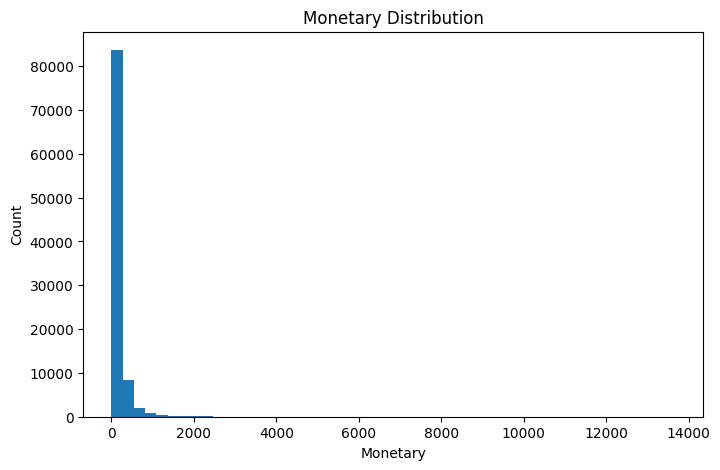

In [31]:
## Monetary 분포
plt.figure(figsize=(8,5))

plt.hist(rfm['monetary'], bins=50)

plt.title('Monetary Distribution')
plt.xlabel('Monetary')
plt.ylabel('Count')

plt.show()

## 대부분 고객은 낮은 구매 금액

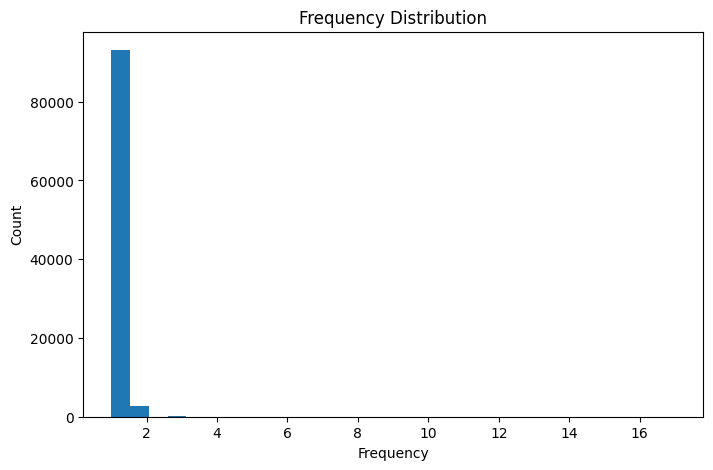

In [32]:
## Frequency 분포

plt.figure(figsize=(8,5))
plt.hist(rfm['frequency'], bins=30)

plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.show()

## 재구매 고객 비율이 상대적으로 적음

In [33]:
## VIP 고객

# 1. RFM 점수화
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    q=5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    q=5,
    labels=[1,2,3,4,5]
)

In [34]:
# 2. 총점
rfm['RFM_score'] = (
    rfm['R_score'].astype(int)
    + rfm['F_score'].astype(int)
    + rfm['M_score'].astype(int)
)

rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,6
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,7


In [35]:
# 3. 점수 분포
rfm['RFM_score'].value_counts().sort_index()

RFM_score
3       814
4      2427
5      4842
6      7800
7     11402
8     13710
9     14427
10    13508
11    11208
12     7678
13     4729
14     2493
15     1057
Name: count, dtype: int64

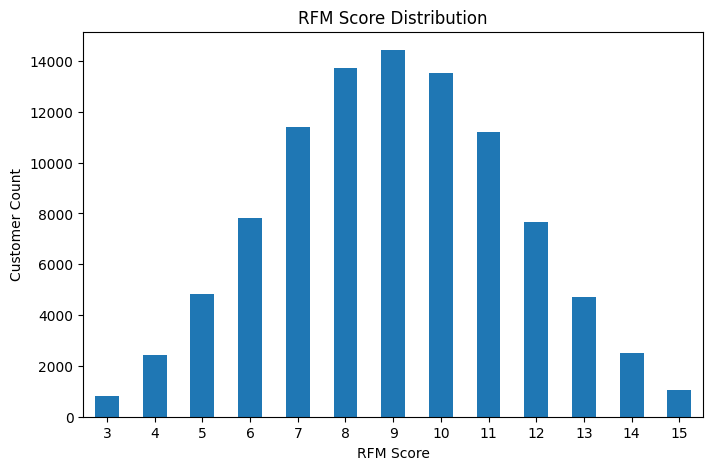

In [36]:
# 4. 분포 시각화
plt.figure(figsize=(8,5))

rfm['RFM_score'].value_counts()\
    .sort_index()\
    .plot(kind='bar')

plt.xticks(rotation=0)

plt.title('RFM Score Distribution')
plt.xlabel('RFM Score')
plt.ylabel('Customer Count')

plt.show()

In [37]:
# 5. 고객 세그먼트 생성
def segment_customer(score):
    if score >= 13:
        return 'VIP'
    elif score >= 10:
        return 'Loyal'
    elif score >= 7:
        return 'Regular'
    else:
        return 'At Risk'

rfm['segment'] = rfm['RFM_score'].apply(
    segment_customer
)
rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,9,Regular
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,6,At Risk
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,4,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,4,At Risk
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,7,Regular


In [38]:
rfm['segment'].value_counts()

segment
Regular    39539
Loyal      32394
At Risk    15883
VIP         8279
Name: count, dtype: int64

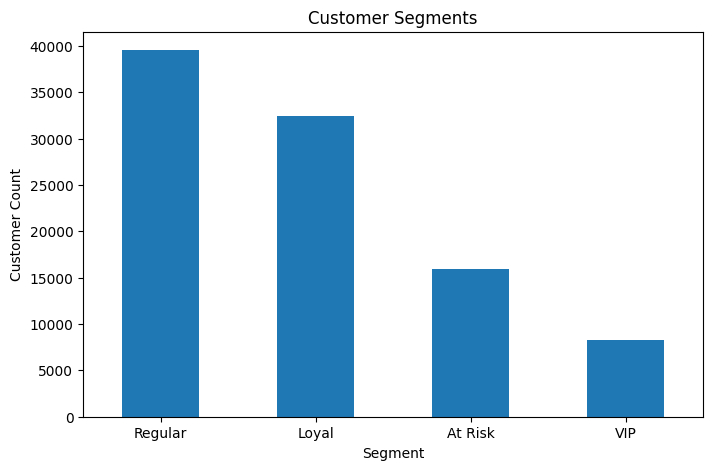

In [39]:
# 고객 세그먼트 시각화
plt.figure(figsize=(8,5))

rfm['segment']\
    .value_counts()\
    .plot(kind='bar')

plt.xticks(rotation=0)

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Customer Count')

plt.show()

#

고객 세그먼트 분석 결과, Regular 고객의 비중이 가장 높게 나타났다. Loyal 고객 역시 상당한 비중을 차지하고 있어 플랫폼 내에서 반복 구매가 발생하고 있는 것으로 보임.

반면 VIP 고객은 상대적으로 적은 비중을 차지했으며, 핵심 고객군을 유지하고 확대하기 위한 전략이 필요해 보임.

또한 At Risk 고객도 일정 규모 존재하여 재구매를 유도하기 위한 프로모션이나 고객 관리 방안을 고려할 수 있을 것으로 보임.

In [40]:
freq_count = (
    rfm['frequency']
    .value_counts()
    .sort_index()
    .reset_index()
)

freq_count.columns = ['frequency', 'customer_count']

freq_count.head(20)

,frequency,customer_count
0,1,93098
1,2,2745
2,3,203
3,4,30
4,5,8
5,6,6
6,7,3
7,9,1
8,17,1


In [41]:
freq_percent = (
    rfm['frequency']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

freq_percent.round(2)

frequency
1     96.88
2      2.86
3      0.21
4      0.03
5      0.01
6      0.01
7      0.00
9      0.00
17     0.00
Name: proportion, dtype: float64

In [42]:
rfm['frequency'].value_counts().sort_index()

frequency
1     93098
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

**고객 세분화를 위해 RFM 분석을 수행**
- Frequency 분포를 확인한 결과 전체 고객의 약 97%가 1회 구매 고객으로 나타남.

- 본 데이터셋은 고객 재구매 패턴이 매우 제한적이었으며, RFM 세분화의 활용도가 높지 않은 특성을 보임.

In [4]:
## 상위 10% 고객이 전체 매출의 몇 %를 만드는가?

query = """
SELECT
    c.customer_unique_id,
    SUM(oi.price) AS revenue

FROM customers c

JOIN orders o
    ON c.customer_id = o.customer_id

JOIN order_items oi
    ON o.order_id = oi.order_id

GROUP BY c.customer_unique_id
"""

df_customer_revenue = pd.read_sql(query, engine)

df_customer_revenue.head()

,customer_unique_id,revenue
0,55a269f324455e78349e7b9b7e7e5911,99.00
1,8797820f6554668a5b835ff74cd077df,46.86
2,c555d42202667b1e09e50e7667b6a663,199.00
3,a046d29175845b313e52f2dff96cc050,173.00
4,26f8790baee110479bb7cb362e16134a,21.99


In [8]:
df_customer_revenue = df_customer_revenue.sort_values(
    by='revenue',
    ascending=False
)

df_customer_revenue['cum_revenue_pct'] = (
    df_customer_revenue['revenue'].cumsum()
    / df_customer_revenue['revenue'].sum()
    * 100
)

df_customer_revenue['customer_pct'] = (
    range(1, len(df_customer_revenue)+1)
)

df_customer_revenue['customer_pct'] = (
    df_customer_revenue['customer_pct']
    / len(df_customer_revenue)
    * 100
)

df_customer_revenue.head()

,customer_unique_id,revenue,cum_revenue_pct,customer_pct
26098,0a0a92112bd4c708ca5fde585afaa872,13440.0,0.098884,0.001048
5050,da122df9eeddfedc1dc1f5349a1a690c,7388.0,0.153241,0.002096
29385,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,0.205921,0.003144
46862,dc4802a71eae9be1dd28f5d788ceb526,6735.0,0.255473,0.004192
70418,459bef486812aa25204be022145caa62,6729.0,0.304982,0.005240


In [6]:
# 상위 10% 고객의 매출

df_customer_revenue[
    df_customer_revenue['customer_pct'] <= 10
]['revenue'].sum() / df_customer_revenue['revenue'].sum() * 100

np.float64(41.23276164162544)

**고객 매출 집중도 분석 결과**
- 상위 10% 고객이 전체 매출의 약 41%를 차지함.
- 일부 고객이 매출에 상당한 영향을 미치고 있음을 보여주지만, 특정 소수 고객에게 지나치게 의존하는 구조는 아님.
- 전체 고객의 약 97%가 1회 구매 고객임에도 불구하고 상위 고객군이 높은 매출 기여도를 보이고 있음. -> 고객별 구매 금액 차이가 존재함 확인.

### 지역 분석

In [72]:
## 지역별 매출

query = """
SELECT
    c.customer_state,
    ROUND(SUM(oi.price), 2) AS revenue

FROM customers c

JOIN orders o
    ON c.customer_id = o.customer_id

JOIN order_items oi
    ON o.order_id = oi.order_id

GROUP BY c.customer_state

ORDER BY revenue DESC;
"""

df_state_revenue = pd.read_sql(query, engine)

df_state_revenue.head(10)

,customer_state,revenue
0,SP,5202955.05
1,RJ,1824092.67
2,MG,1585308.03
3,RS,750304.02
4,PR,683083.76
5,SC,520553.34
6,BA,511349.99
7,DF,302603.94
8,GO,294591.95
9,ES,275037.31


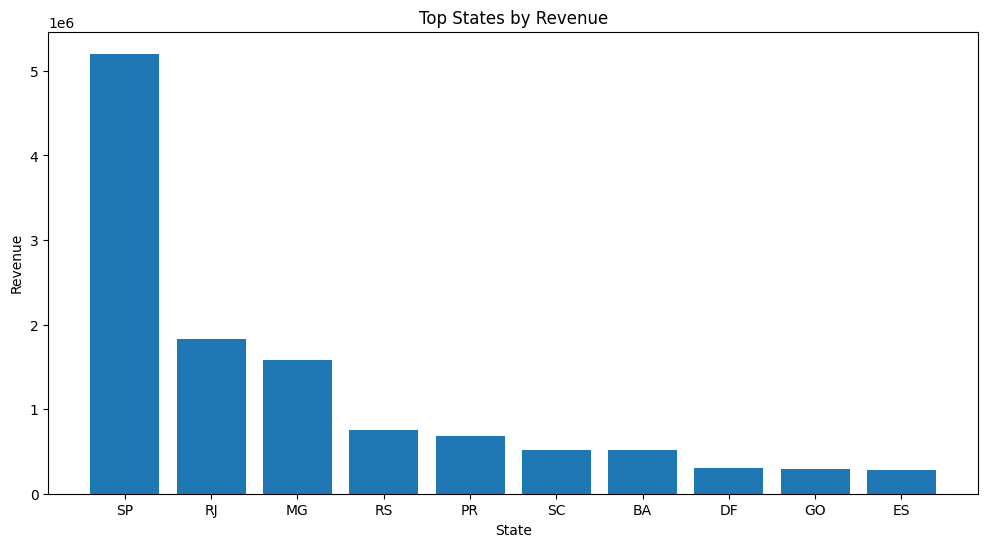

In [74]:
plt.figure(figsize=(12,6))

plt.bar(
    df_state_revenue['customer_state'][:10],
    df_state_revenue['revenue'][:10]
)

plt.title('Top States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

- 지역별 매출 분석 결과, SP가 약 520만의 매출을 기록하며 가장 높은 매출을 보임.
- 2위 지역인 RJ보다 약 2.8배 높은 수준으로 Olist의 핵심 시장이 SP지역에 집중되어 있음.
- 상위 3개 지역(SP, RJ, MG)이 전체 매출의 상당 부분을 차지하고 있어 브라질의 경제 중심 지역과 전자상거래매출간의 연관성을 확인할 수 있음.

In [75]:
## 지역별 고객수

query = """
SELECT
    customer_state,
    COUNT(DISTINCT customer_id) AS customer_count

FROM customers

GROUP BY customer_state

ORDER BY customer_count DESC;
"""

df_state_customer = pd.read_sql(query, engine)

df_state_customer.head(10)


,customer_state,customer_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [78]:
## 고객 1인당 평균 매출

df_state_analysis = pd.merge(
    df_state_revenue,
    df_state_customer,
    on='customer_state'
)

df_state_analysis['revenue_per_customer'] = (
    df_state_analysis['revenue']
    / df_state_analysis['customer_count']
)

df_state_analysis.sort_values(
    by='revenue_per_customer',
    ascending=False
).head(10)

,customer_state,revenue,customer_count,revenue_per_customer
16,PB,115268.08,536,215.052388
25,AP,13474.30,68,198.151471
24,AC,15982.95,81,197.320370
19,AL,80314.81,413,194.466852
12,PA,178947.81,975,183.536215
22,RO,46140.64,253,182.374071
21,TO,49621.74,280,177.220500
17,PI,86914.08,495,175.584000
13,MT,156453.53,907,172.495623
18,RN,83034.98,485,171.206144


- 총매출 기준으로는 SP가 가장 중요한 시장으로 나타남. 
- 고객 1인당 평균 매출을 기준으로 분석한 결과 PB, AP, AC 지역이 상대적으로 높은 소비 수준을 보여주나 해당 지역은 고객 수가 적어 매출 기여도는 제한적임. 

- ->  Olist의 핵심 시장은 여전히 고객 기반이 큰 SP, RJ, MG 지역으로 판단됨.

### 고객 경험 분석
배송지연여부 - 리뷰 점수 관계

In [11]:
## 배송 지연일수 계산
# (-) = 예상보다 빨리 도착, (0) = 예정일 도착, (+) = 배송 지연

query = """
SELECT
    review_score,

    DATEDIFF(
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date
    ) AS delay_days

FROM orders o

JOIN reviews r
    ON o.order_id = r.order_id

WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL
"""

df_delay = pd.read_sql(query, engine)

df_delay.head()

,review_score,delay_days
0,4,-16
1,5,-10
2,5,-15
3,5,-15
4,5,-16


In [12]:
## 지연 구간 만들기

df_delay['delay_group'] = pd.cut(
    df_delay['delay_days'],
    bins=[-100, -1, 0, 3, 7, 100],
    labels=[
        'Early',
        'On Time',
        '1~3 Days Late',
        '4~7 Days Late',
        '7+ Days Late'
    ]
)

In [13]:
## 구간별 리뷰 평균

delay_review = (
    df_delay
    .groupby('delay_group')['review_score']
    .mean()
    .reset_index()
)

delay_review

,delay_group,review_score
0,Early,4.293701
1,On Time,4.033308
2,1~3 Days Late,3.289871
3,4~7 Days Late,2.104214
4,7+ Days Late,1.682246


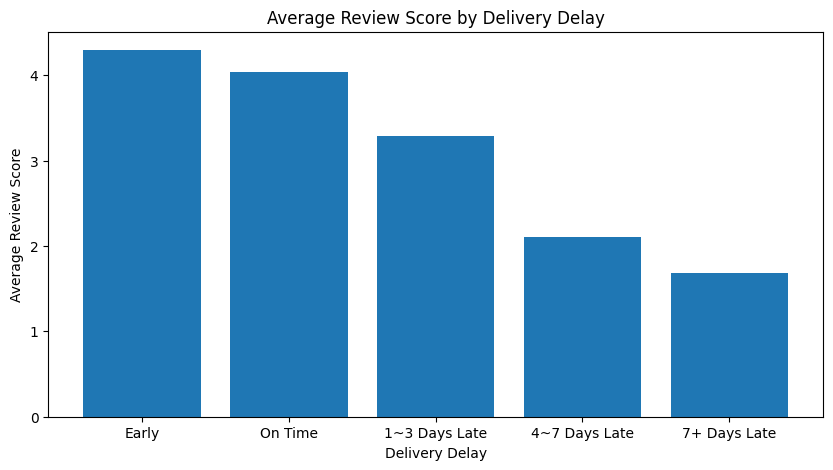

In [15]:
plt.figure(figsize=(10,5))

plt.bar(
    delay_review['delay_group'],
    delay_review['review_score']
)

plt.title('Average Review Score by Delivery Delay')
plt.xlabel('Delivery Delay')
plt.ylabel('Average Review Score')

plt.show()

# 배송이 늦을수록 리뷰 점수가 꾸준히 하락

In [16]:
delay_review_count = (
    df_delay
    .groupby(['delay_group','review_score'])
    .size()
    .unstack(fill_value=0)
) # .size() - 각 그룹의 개수 세기, .unstack() - 행과 열을 바꿔서 보기 좋게 만듦. 없는 경우 NaN이 아닌 0으로 표시.

delay_review_count

review_score,1,2,3,4,5
delay_group,,,,,
Early,5851,2335,7085,18033,55344
On Time,110,50,178,302,651
1~3 Days Late,467,130,272,372,615
4~7 Days Late,1028,160,173,147,248
7+ Days Late,1936,264,249,123,188


In [17]:
delay_review_pct = (
    delay_review_count.div(
        delay_review_count.sum(axis=1),
        axis=0
    ) * 100
)

delay_review_pct.round(2)

review_score,1,2,3,4,5
delay_group,,,,,
Early,6.60,2.63,7.99,20.34,62.43
On Time,8.52,3.87,13.79,23.39,50.43
1~3 Days Late,25.16,7.00,14.66,20.04,33.14
4~7 Days Late,58.54,9.11,9.85,8.37,14.12
7+ Days Late,70.14,9.57,9.02,4.46,6.81


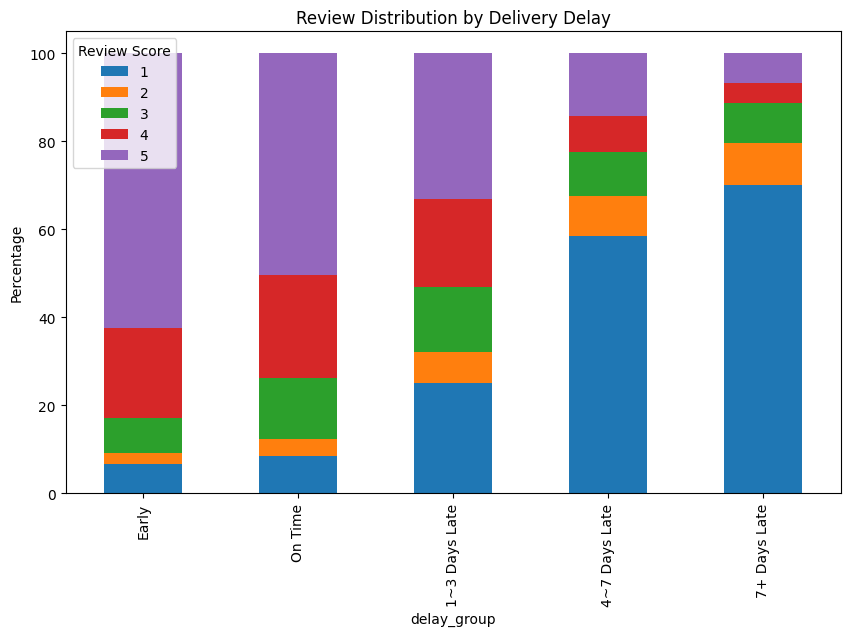

In [18]:
delay_review_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Review Distribution by Delivery Delay')
plt.ylabel('Percentage')
plt.legend(title='Review Score')
plt.show()

**배송 지연 일수와 리뷰 점수 간의 관계 분석 결과**
- 배송이 늦어질수록 고객 만족도가 급격하게 하락하는 경향 확인
- 예정보다 빠르게 배송된 주문의 경우 5점 리뷰 비율 62.4%였으나 7일 이상 지연된 주문은 5점 리뷰 비율이 6.8%에 불과함.
- 반대로 1점 리뷰 비율을 Early 그룹에서 6.6%였으나, 7일 이상 지연 그룹에서는 70.1%까지 증가함.
- 배송 지연은 고객 만족도 하락에 직접적인 영향을 미치는 핵심 요인임을 확인함.